In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import glob as glob
import os
from importlib import reload
%matplotlib inline
import sys
sys.path.append("modules")
import bedgraph_tools as bgt
import peak_tools as pkt
from collections import defaultdict
import pyBigWig as pw
import pysam
from itertools import groupby
from Bio import motifs
import logomaker
from Bio import Align
from Bio.Seq import Seq
%config InlineBackend.figure_format='retina'
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
from scipy import stats
from scipy.interpolate import interp1d
import matplotlib.colors as mcolors
import upsetplot
from scipy.ndimage import uniform_filter
aligner = Align.PairwiseAligner()


/home/labs/barkailab/vovam/miniconda/envs/iran/lib/python3.11/site-packages/sorted_nearest/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def prepare_for_QC_plot(df, tf):
    br = pd.concat([pd.read_csv(x, index_col=0) for x in df.loc[:, 'Bad_Regs'].values], axis=0)
    # df = pd.concat([df, br], axis=1)
    if tf == 'SMAD':
        t_c = pd.DataFrame(br.reset_index().loc[:, 'index']\
                           .apply(lambda x: ['Treat', 'cornflowerblue'] if 'BMP' in x else ['Control', 'gray']).to_dict()).T
    elif tf == 'other':
        t_c = pd.DataFrame(br.reset_index().loc[:, 'index']\
                           .apply(lambda x: ['Treat', 'cornflowerblue'] if 'lbd' in x.lower() else ['Control', 'gray']).to_dict()).T
    else:
        t_c = pd.DataFrame(br.reset_index().loc[:, 'index']\
                           .apply(lambda x: ['Treat', 'cornflowerblue'] if 'lig' in x else ['Control', 'gray']).to_dict()).T
    t_c.index = br.index
    t_c.columns = ['Treat', 'Color']
    br = pd.concat([br, t_c], axis=1)
    br = pd.concat([br, df.loc[:,['RawBG', 'Read1BG']]], axis=1)
    br.loc[:, 'Sample'] = ['_'.join(x.split('_')[:-3]) for x in br.index]
    return br


def draw_ecdf(data, reads_thresh, ax, c):
    
    draw = data.filter(pl.col('Value')==reads_thresh)['distance'].drop_nulls()
    if draw.shape[0]>100:
        ax.ecdf(draw, label=reads_thresh, c=c)

def load_bedgraph(path):
    """
    Load a bedgraph file into a Polars DataFrame.

    Args:
        path (str): Path to the bedgraph file.

    Returns:
        pl.DataFrame: A Polars DataFrame with the bedgraph data.
    """
    return pl.read_csv(
        path,
        separator="\t",
        has_header=False,
        new_columns=["Chromosome", "Start", "End", "Value"],
    )



def plot_QC(df, analyzed, save=False, save_path=''):

    bins_val = [20,100,500,1000,2000,10000]
    ecdf_palette = sns.color_palette('Blues', n_colors=10)

    fig = plt.figure(figsize=(12,3), dpi=200)
    subf = fig.subfigures(1,3, width_ratios=[1,2,2])
    coverage_ax = subf[1].subplots(1)
    bll_ax, bins_ax = subf[0].subplots(2,1) 
    # bins_ax = subf[2].subplots(1)
    dist_ax = subf[2].subplots(2,1, sharex=True)

    bins_d = dict()
    for index,_,_,label,color,pathi, pathr1, sample in df.reset_index().values:


        loaded_clean = load_bedgraph(pathi)
        loaded_clean = bgt.expand_data(loaded_clean)
        loaded_clean = bgt.clean_bg(loaded_clean, mask)
        loaded_r1 = load_bedgraph(pathr1).pipe(bgt.expand_data).pipe(bgt.clean_bg, mask)

        dat = bgt.calc_frac_cov(loaded_clean, "Value")
        coverage_ax.plot(dat['Value'], dat['fraction'], label=label, c=color )

        calc = []
        for i in bins_val:
            treat = bgt.divide_bins(bgt.normalize_to_rpm(loaded_r1, 'Value'), i).group_by(["Chromosome", "bin_start", "bin_end"]).agg(
                    pl.col("Value").sum().alias("Mean_per_bin"))
            calc.append(treat['Mean_per_bin'].mean())

        distances = bgt.calculate_inter_read_distances(loaded_r1)


        if label == 'Treat':
            nax = dist_ax[0]
        else:
            nax = dist_ax[1]
        draw_ecdf(distances, 1, nax, c=ecdf_palette[0])
        draw_ecdf(distances, 2, nax, c=ecdf_palette[1])
        draw_ecdf(distances, 3, nax, c=ecdf_palette[2])
        draw_ecdf(distances, 4, nax, c=ecdf_palette[3])
        draw_ecdf(distances, 5, nax, c=ecdf_palette[4])
        draw_ecdf(distances, 6, nax, c=ecdf_palette[5])
        draw_ecdf(distances, 7, nax, c=ecdf_palette[6])
        draw_ecdf(distances, 8, nax, c=ecdf_palette[7])
        draw_ecdf(distances, 9, nax, c=ecdf_palette[8])
        draw_ecdf(distances, 10, nax, c=ecdf_palette[9])

        nax.set_xscale('log')
        nax.set_ylabel('ECDF')
        nax.axvline(100, c='k', ls=':', label='100 bp')

        bins_d[index] = calc
    coverage_ax.set_yscale('log')

    coverage_ax.legend()
    coverage_ax.set_xlim([1, 100])
    coverage_ax.set_ylim([1e-7,1])
    coverage_ax.set_xlabel('Coverage >=')
    coverage_ax.set_ylabel('Fraction of covered basepairs')



    bar_dat = df.iloc[:, [0,1,-1]].set_index('Sample').stack().reset_index()
    bar = sns.barplot(bar_dat, x='Sample', y=0, hue='level_1', ax=bll_ax, palette=['gray', 'cornflowerblue'], edgecolor='k', linewidth=1)
    sns.move_legend(bar, 'upper right', bbox_to_anchor=[.8,1.4])
    bll_ax.set_xticklabels(['no ligand', 'ligand'])
    bll_ax.set_ylabel('Fraction of reads')


    scat = pd.concat([df,pd.DataFrame(bins_d, index=bins_val).T], axis=1).loc[:, 'Sample':].set_index('Sample').stack().reset_index()
    scat = scat.groupby(['Sample', 'level_1']).mean().reset_index()
    sns.scatterplot(data=scat, x='level_1', y=0, hue="Sample",ax=bins_ax, palette=['cornflowerblue', 'gray'])
    bins_ax.set_xlabel('Bin width')
    bins_ax.set_ylabel('Mean of sum RPM per bin')
    bins_ax.legend()
    bins_ax.set_yscale('log')
    bins_ax.set_xscale('log')

    dist_ax[0].set_xscale('log')
    dist_ax[1].set_xscale('log')
    dist_ax[1].set_xlabel('Distance between \n neighbour reads (bp)')
    dist_ax[0].legend(bbox_to_anchor=[1.5,1])
    for axi in dist_ax:
        axi.set_ylabel('ECDF')
        axi.axvline(100, c='k', ls=':', label='100 bp')
    if save:
        fig.savefig(save_path)
        plt.close(fig)

def load_and_add_name_col(path, name):
    pp = pr.read_bed(path)
    pp = pp.insert(pd.Series(data = np.char.add(np.arange(len(pp)).astype(str), '_{}'.format(name)), name="Column"))
    return pp
def load_mot(path, mot_path):
    with open(mot_path) as handle:
        cosensus_mot = motifs.read(handle, "pfm-four-columns").consensus

        # Extract the motif sequences (not specifically used below)
    loaded_loc = pd.read_csv(os.path.join(path, 'fimo.tsv'), delimiter='\t').iloc[:-3,: ]#.loc[:, ['motif_id', 'sequence_name', 'start', 'stop', 'strand', 'matched_sequence']]
    seqs = loaded_loc.sort_values(by='score', ascending=False).loc[:, 'matched_sequence']
#     loaded_loc['strand'] = seqs.apply(lambda x: align_mots(cosensus_mot, x, aligner)).values
    return loaded_loc
def align_mots(ref, seq2, aligner=aligner):
    aligned_F = aligner.align(ref, seq2)
    aligned_R = aligner.align(ref, Seq(seq2).reverse_complement())
    
    if aligned_F.score >= aligned_R.score:
        return "+"
    else:
        return "-"
    
def filter_top_quantile(group, quantile=0.9):
    """
    Filters rows in a group where the sum across columns is above the quantile threshold.
    
    Parameters:
        group (pd.DataFrame): Grouped DataFrame.
        quantile (float): The quantile threshold (default 0.9).
        
    Returns:
        pd.DataFrame: Filtered DataFrame with top quantile rows.
    """
    # Compute the sum across all numeric columns per row
    # row_sums = group.loc[:, list(np.arange(75,95).astype(str)) + list(np.arange(105,125).astype(str))].sum(axis=1)
    row_sums = group.loc[:, list(np.arange(200).astype(str))].sum(axis=1)

    # Compute the quantile threshold
    threshold = np.quantile(row_sums, quantile)

    # Return rows that exceed the threshold
    return group[row_sums >= threshold]

def compute_footprint_lengths(x, y, thresholds):
    """
    Compute footprint lengths for multiple percentage thresholds.
    
    Parameters:
        x (array-like): X-values (time or index)
        y (array-like): Y-values (signal intensity)
        thresholds (list): List of percentage drop values (e.g., [0.05, 0.1, 0.5])

    Returns:
        footprint_lengths (dict): Dictionary with thresholds as keys and footprint lengths as values.
    """
    # Interpolation function
    interp_func = interp1d(x, y, kind='linear')

    # Generate more dense x values for interpolation
    window = 600
    x_dense = np.linspace(min(x), max(x), window)
    y_dense = interp_func(x_dense)  # Interpolated y values

    # Find Peak
    peak_index = int(window/2)
    peak_x = x_dense[peak_index]
    peak_y = y_dense[peak_index]

    footprint_lengths = {}

    for threshold in thresholds:
        threshold_value = threshold * peak_y  # Compute threshold level

        # Find left and right drop-off points safely
        left_indices = np.where(y_dense[:peak_index] <= threshold_value)[0]
        right_indices = np.where(y_dense[peak_index:] <= threshold_value)[0]

        left_x = x_dense[left_indices[-1]] if len(left_indices) > 0 else None
        right_x = x_dense[right_indices[0] + peak_index] if len(right_indices) > 0 else None

        # Compute footprint length if both sides exist
        footprint_length = right_x - left_x if left_x is not None and right_x is not None else None

        footprint_lengths[threshold] = footprint_length

    return footprint_lengths



In [3]:
metadata = pd.read_parquet('metadata/metadata.parquet').loc[:, ['index', 'NormBG', 'AverageBw', 'peaks_w_summits', 'BigWig']].fillna('None')
metadata.peaks_w_summits = metadata.peaks_w_summits.apply(lambda x: os.path.join('data/combined_threshed_peaks_wsummits/', x.split('/')[-1]))
metadata.AverageBw = metadata.AverageBw.apply(lambda x: os.path.join('data/AverageBw/', x.split('/')[-1]))
metadata.NormBG = metadata.NormBG.apply(lambda x: [os.path.join('data/NormBG/', k.split('/')[-1]) for k in x])
metadata.BigWig = metadata.BigWig.apply(lambda x: [os.path.join('data/SampleBW/', k.split('/')[-1]) for k in x])

In [4]:
singles_metadata = pd.read_parquet('metadata/singles_metadata.parquet')
masked_region = 'data/auxilary/masked_mm10.bed'
mask = pr.read_bed(masked_region)
wts = singles_metadata.filter(regex='lig|WT|SMAD1',axis=0)


screen_mm10 = pd.read_csv('data/auxilary/encodeCcreCombinedmm10.bed', delimiter='\t', header=None)
columns = ['Chromosome','Start','End','name','score','strand','thickStart','thickEnd','reserved','ccre','encodeLabel','zScore','ucscLabel','accessionLabel','description']
screen_mm10.columns = columns

In [5]:
os.makedirs('figures/Fig1', exist_ok=True)

In [6]:
reload(bgt)
mAR = wts.filter(regex='mAR', axis=0)
a = plot_QC(prepare_for_QC_plot(mAR, 'NR'), 'nmnumgGR', save=True, save_path='figures/Fig1/1C.pdf')


/home/labs/barkailab/vovam/submission_git/Steroid_Receptors/ZigShoMinMan_2025/modules/bedgraph_tools.py:429: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  expanded_df = pl.DataFrame(expanded_rows, schema=['Chromosome', 'Start', 'End', 'Value'])
/home/labs/barkailab/vovam/submission_git/Steroid_Receptors/ZigShoMinMan_2025/modules/bedgraph_tools.py:429: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  expanded_df = pl.DataFrame(expanded_rows, schema=['Chromosome', 'Start', 'End', 'Value'])
/home/labs/barkailab/vovam/submission_git/Steroid_Receptors/ZigShoMinMan_2025/modules/bedgraph_tools.py:429: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this 

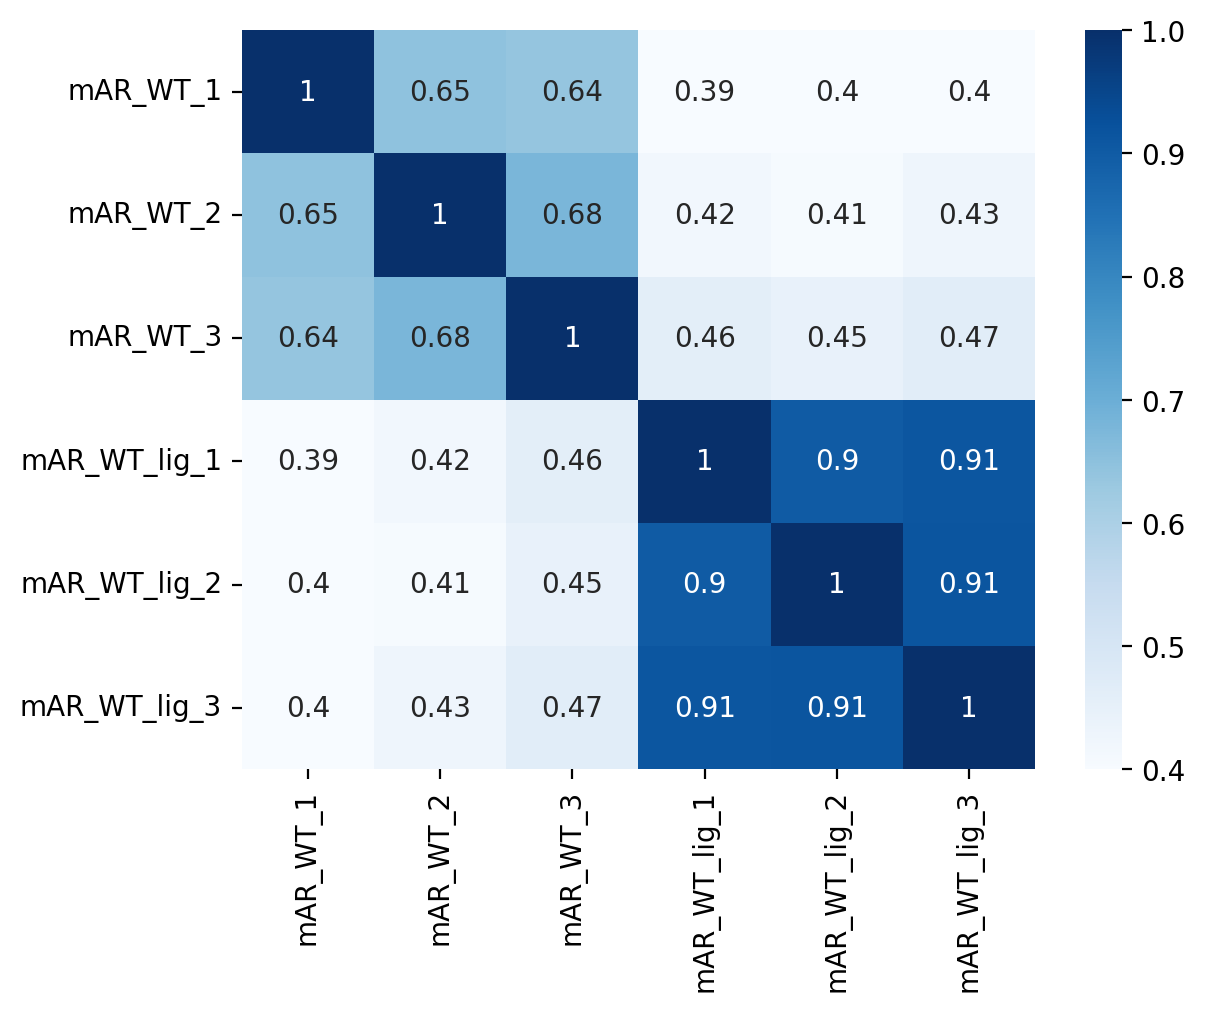

In [8]:
gr = metadata.filter(regex='wt|lig', axis=0).filter(regex='nmumg', axis=0).filter(regex='ar', axis=0)
peak = gr.loc['nmumg_mar_wt_lig', 'peaks_w_summits']
peak = pr.read_bed(peak).df


for cbw in np.concatenate(gr.loc[:, ['BigWig']].values.T[0]):
    bwi = pw.open(cbw)
    a = []
    for i in peak.loc[:, ['Chromosome', 'Start', 'End']].values:
        a.append(bwi.values(i[0], i[1], i[2], numpy=True).sum())
    peak.loc[:, cbw.split('/')[-1].split('_S')[0]] = a
    bwi.close()
    
fig, ax = plt.subplots(1)
sns.heatmap(peak.filter(regex='AR').corr(), cmap='Blues', ax=ax, annot=True, vmin=.4)
fig.savefig('figures/Fig1/1D_2.pdf')

In [9]:
t = metadata.filter(regex='lig|bmp', axis=0).filter(regex='nmumg', axis=0).loc[:, 'peaks_w_summits']

nmumg_fimo = sorted(glob.glob('data/combined_threshed_peaks_wsummits/output_fimo_fasta_*'))
arr = np.array(list((pd.Index(nmumg_fimo).str.split('output_fimo_fasta_').str[1].str.split('_fc10_'))))

pivoted = pd.DataFrame((arr[:,0], arr[:, 1], nmumg_fimo)).T\
.pivot(index=0, columns=1, values=2)\
.rename_axis(None, axis=1)\
.rename_axis('index', axis=0)

nmummg_wtlig_mot_locs = pivoted
md = {'smad1':'SMAD1', 'hgr':'GR', 'mar':'AR', 'hpr':'PR', 'ar':'AR', 'pr':'PR', 'gr':'GR'}

mot_num_table = defaultdict(list)
peak_shape = dict()
for key, value in t.to_dict().items():
    print(key)
    if key == 'nmumg_smad1':
        key = 'nmumg_smad1_bmp_high'
    clocs = nmummg_wtlig_mot_locs.filter(regex=md[key.split('_')[1]]).loc[key]
    lpeak = pr.read_bed(value)
    peak_shape[key] = len(lpeak)
    clocs = clocs.fillna('data/combined_threshed_peaks_wsummits/output_fimo_fasta_nmumg_smad1_bmp_high_fc10_SMAD1_HNF_mot')
    for cmot, cloc in clocs.reset_index().values:
        loaded_loc = pr.read_gff3(cloc + '/fimo.gff')
        mot_num_table[key].append((cmot, lpeak.join(loaded_loc).cluster().Cluster.max()))

nmumg_hgr_wt_lig
nmumg_hpr_wt_lig
nmumg_mar_wt_lig
nmumg_smad1_bmp_high


/home/labs/barkailab/vovam/miniconda/envs/iran/lib/python3.11/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)


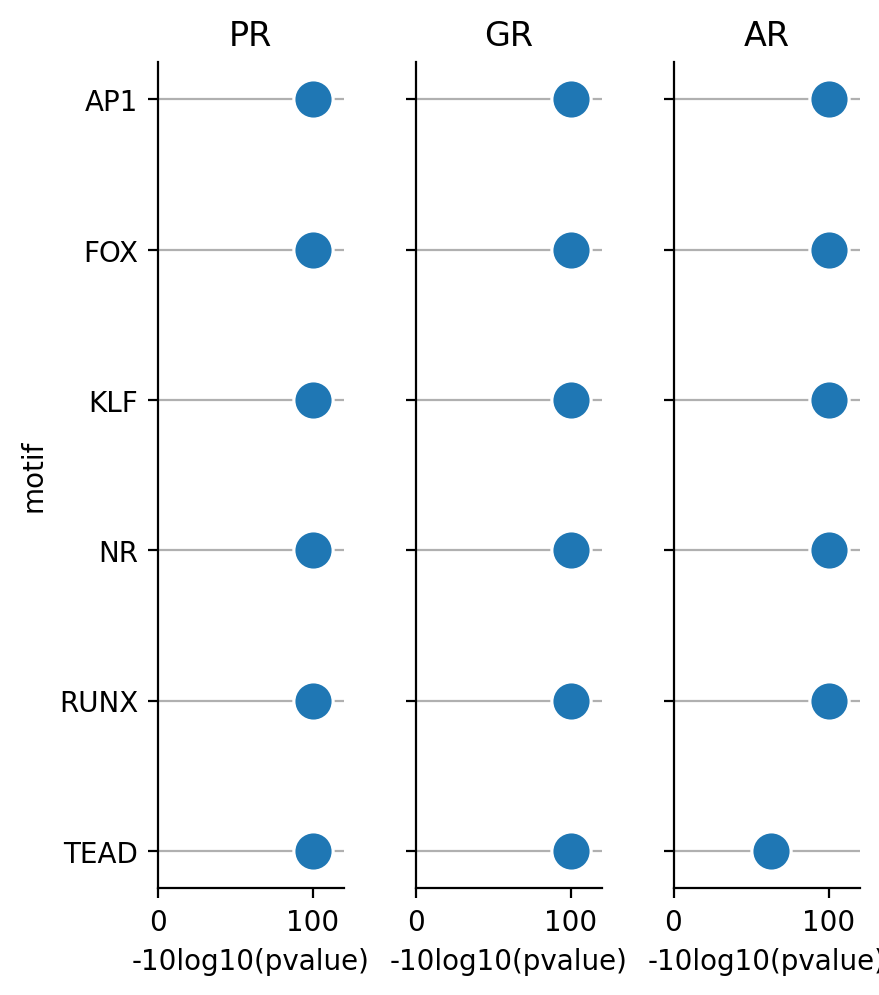

In [10]:
sea = glob.glob('data/combined_threshed_peaks_wsummits/output_sea_fasta_*')

import os
def proc(x):
    return pd.read_csv(os.path.join(x, 'sea.tsv'), delimiter='\t').iloc[:-3, ]\
    .loc[:, ['ID', 'PVALUE']]\
    .rename({'PVALUE':x.split('_fasta_')[-1].split('_fc10')[0]},axis=1)\
    .set_index('ID')
#     pd.read_csv( 'combined_threshed_peaks_wsummits/output_sea_fasta_nmumg_mar_wt_lig_fc10.bed.fasta/sea.tsv',
#            delimiter='\t')

enrich_table = pd.concat([proc(x) for x in sea], axis=1)

ndata = enrich_table.filter(regex='nmumg').filter(regex='lig').filter(regex='AR|GR|PR', axis=0).filter(regex='KLF|AP1|NR|TEAD|FOX|RUNX', axis=0)


ndata.loc[:, 'mot_type'] = ndata.reset_index().loc[:, 'ID'].apply(lambda x: x.split('_')[-1]).values
pvals = -10 * np.log10(ndata.groupby('mot_type').median())
pvals = pvals.replace(np.inf, 2000)
pvals[pvals>100] = 100
pvals = pvals.reset_index().sort_values(by='nmumg_hgr_wt_lig', ascending=False)

g = sns.PairGrid(pvals,
                 x_vars=pvals.columns[1:], y_vars=pvals.columns[0],
                 height=5, aspect=.3, layout_pad=1)

# Draw a dot plot using the stripplot function
g.map(sns.scatterplot, zorder=20, s=200)

g.set(xlim=(0, 120), xlabel= '-10log10(pvalue)', ylabel="motif")

for ax, title in zip(g.axes.flat, ['PR', 'GR', 'AR']):

    # Set a different title for each axes
    ax.set(title=title)

    # Make the grid horizontal instead of vertical
    ax.xaxis.grid(False)
    ax.yaxis.grid(True)
g.fig.savefig('figures/Fig1/1F.pdf')

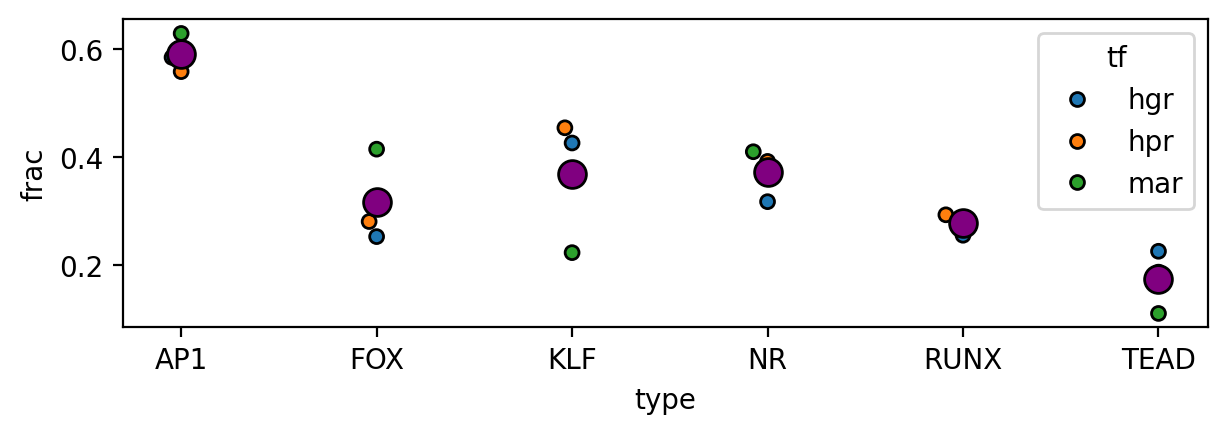

In [11]:

motn_Df = pd.DataFrame(mot_num_table).T.unstack().reset_index().drop('level_0', axis=1)
motn_Df.loc[:, 'mot_source'] = motn_Df.loc[:, 0].apply(lambda x: x[0])
motn_Df.loc[:, 'mot_len'] = motn_Df.loc[:, 0].apply(lambda x: x[1])
mot_table = motn_Df.drop(0, axis=1).pivot(index='level_1', columns='mot_source', values='mot_len')
motn_Df = pd.concat([motn_Df.set_index('level_1') , pd.DataFrame(peak_shape, index=['num_peaks']).T.loc[motn_Df.set_index('level_1').index]], axis=1).reset_index()
motn_Df.loc[:, 'type'] = motn_Df.mot_source.apply(lambda x: x.split('_')[1])

nmotsnmumg = motn_Df.\
set_index('mot_source').\
set_index('level_1').filter(regex='nmumg', axis=0).filter(regex='lig|lbd$|dbd', axis=0)
nmotsnmumg.loc[:, 'frac'] = (nmotsnmumg.mot_len / nmotsnmumg.num_peaks).values
nmotsnmumg = nmotsnmumg.reset_index()
nmotsnmumg.loc[:, 'tf'] = nmotsnmumg.iloc[:,0].apply(lambda x: x.split('_')[1])
nmotsnmumg = nmotsnmumg.set_index('type').drop(['CTCF', 'halfsite']).reset_index()

fig, ax = plt.subplots(1, figsize=(7,2))
sns.swarmplot(data=nmotsnmumg.set_index('level_1').filter(regex='lig', axis=0), x='type', y='frac', c='lightgray', edgecolor='k', linewidth=1, hue='tf')
ax.scatter(data=nmotsnmumg.set_index('level_1').filter(regex='lig', axis=0).loc[:, ['type', 'frac']].groupby('type').mean().reset_index(), x='type', y='frac', zorder=20, s=100, c='purple', ec='k')
fig.savefig('figures/Fig1/1G.pdf')